# MNIST Image Classification: MLP vs CNN
### SWE012 — Deep Learning with Python | Team FCB

---

## Project Overview

This notebook investigates **MNIST handwritten digit classification** as a methodological case study comparing two fundamentally different neural network architectures:

- **MLP (Multi-Layer Perceptron)** — treats each pixel as an independent feature; no spatial prior
- **CNN (Convolutional Neural Network)** — explicitly encodes spatial structure via local receptive fields and weight sharing

The goal is not simply to achieve high accuracy, but to **understand why CNN outperforms MLP on image data** and to quantify the effect of regularization techniques on both architectures.

---

## Dataset: MNIST

| Property | Value |
|---|---|
| Input shape | 28 × 28 grayscale images |
| Classes | 10 (digits 0–9) |
| Training set | 50,000 images |
| Validation set | 10,000 images |
| Test set | 10,000 images (official MNIST test split) |

**Preprocessing:** Pixel values are normalised from [0, 255] to [0.0, 1.0] by dividing by 255. No augmentation is applied — both models train under identical conditions.

---

## Notebook Structure

| Section | Content |
|---|---|
| 1 | Setup, data loading, preprocessing |
| 2 | MLP — architecture, training, results |
| 3 | CNN — architecture, training, results |
| 4 | Baseline comparison (val curves, test metrics) |
| 5 | **Overfitting analysis** — train vs val gap |
| 6 | **Architectural decision rationale** |
| 7 | **Regularization ablation study** (MLP+Dropout, CNN+BN+Dropout) |
| 8 | **4-model comparative analysis** |
| 9 | **Confusion matrix interpretation** |
| 10 | **Per-class accuracy breakdown** |
| 11 | Final summary and key findings |


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

tf.keras.utils.set_random_seed(42)

(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


x_val = x_train_full[-10000:]
y_val = y_train_full[-10000:]
x_train = x_train_full[:-10000]
y_train = y_train_full[:-10000]

# CNN: add channel dimension (N, 28, 28, 1)
x_train_cnn = np.expand_dims(x_train, -1)
x_val_cnn = np.expand_dims(x_val, -1)
x_test_cnn = np.expand_dims(x_test, -1)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape, y_val.shape)
print("Test: ", x_test.shape, y_test.shape)
print("GPUs: ", tf.config.list_physical_devices("GPU"))

Train: (50000, 28, 28) (50000,)
Val:   (10000, 28, 28) (10000,)
Test:  (10000, 28, 28) (10000,)
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Model A: Multi-Layer Perceptron (MLP)

### Architecture

```
Input (28×28) → Flatten (784) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(10, Softmax)
```

### Design Rationale

| Layer | Choice | Reason |
|---|---|---|
| `Flatten` | Required | MLP cannot process 2D input; flattens 28×28 into 784 features |
| `Dense(256, relu)` | 256 neurons | ~1/3 of input size (784); balances capacity vs overfitting risk |
| `Dense(128, relu)` | 128 neurons | Funnel architecture: each layer halves the previous → gradual abstraction |
| `Dense(10, softmax)` | 10 outputs | One per class; softmax produces a valid probability distribution |
| `ReLU` | Activation | No vanishing gradient; computationally efficient: max(0, x) |

### Expected Behaviour

The MLP has **no spatial prior** — it treats every pixel as an independent feature and must learn spatial relationships from scratch. This makes it more prone to overfitting on image data compared to a CNN.


In [3]:
mlp = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="mlp")

mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_mlp = mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
)

I0000 00:00:1775330480.475209      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/15


I0000 00:00:1775330482.851691     123 service.cc:152] XLA service 0x7a166c0057d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775330482.851722     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775330483.083289     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


 75/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6711 - loss: 1.1244

I0000 00:00:1775330483.748200     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8418 - loss: 0.5443 - val_accuracy: 0.9591 - val_loss: 0.1437
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9595 - loss: 0.1364 - val_accuracy: 0.9654 - val_loss: 0.1101
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0866 - val_accuracy: 0.9707 - val_loss: 0.0971
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0585 - val_accuracy: 0.9695 - val_loss: 0.0990
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9678 - val_loss: 0.1097
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0283 - val_accuracy: 0.9705 - val_loss: 0.1075
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9943 - loss: 0.0212 - val_accuracy: 0.9709 - val_loss: 0.1152
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9738 - val_

## Model B: Convolutional Neural Network (CNN)

### Architecture

```
Input (28×28×1)
  → Conv2D(32, 3×3, same) → MaxPool(2×2)
  → Conv2D(64, 3×3, same) → MaxPool(2×2)
  → Flatten → Dense(128, ReLU) → Dense(10, Softmax)
```

### Design Rationale

| Layer | Choice | Reason |
|---|---|---|
| `Conv2D(32, 3, same)` | 32 filters, 3×3 kernel | Captures low-level features (edges, corners). 3×3 is the standard for image tasks — balances local connectivity with parameter efficiency. `padding='same'` preserves 28×28 spatial size. |
| `MaxPooling2D(2)` | 2×2 pool | Halves spatial dims (28→14). Provides translation invariance. Reduces parameters. |
| `Conv2D(64, 3, same)` | 64 filters | 2× the first block — learns higher-level feature combinations (stroke parts, digit segments). |
| `MaxPooling2D(2)` | 2×2 pool | Further reduction: 14→7. |
| `Dense(128, relu)` | 128 neurons | Combines global spatial features before classification. |
| `Dense(10, softmax)` | 10 outputs | Same as MLP — mandatory for 10-class output. |

### Key Advantage over MLP

**Weight sharing:** The same 3×3 filter scans every spatial position. This means the CNN learns "what an edge looks like" once, and reuses that knowledge everywhere — unlike MLP which must re-learn it for every pixel position independently.

**Parameter comparison (after training):**

| Model | Parameters |
|---|---|
| MLP | 235,146 |
| CNN | 421,642 |

> Despite having more parameters, CNN generalises better. The advantage comes from **inductive bias**, not raw capacity.

In [4]:
cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="cnn")

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8410 - loss: 0.5164 - val_accuracy: 0.9812 - val_loss: 0.0642
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9797 - loss: 0.0686 - val_accuracy: 0.9830 - val_loss: 0.0537
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9861 - loss: 0.0465 - val_accuracy: 0.9829 - val_loss: 0.0523
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.9841 - val_loss: 0.0520
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0251 - val_accuracy: 0.9843 - val_loss: 0.0509
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.9834 - val_loss: 0.0643
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9949 - loss: 0.0152 - val_accuracy: 0.9862 - val_loss: 0.0580
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.


## Baseline Comparison: MLP vs CNN

Both models are trained under **identical conditions** to ensure a fair comparison:

| Setting | Value |
|---|---|
| Optimizer | Adam |
| Loss | sparse_categorical_crossentropy |
| Epochs | 15 |
| Batch size | 128 |
| Random seed | 42 |
| Train/Val/Test split | 50k / 10k / 10k |

The plots below show **validation accuracy** and **validation loss** across all 15 epochs. A well-generalising model should show:
- Validation accuracy close to training accuracy (small gap)
- Smooth, decreasing validation loss

# Setup + reproducibility + MNIST loading + train/val/test splits

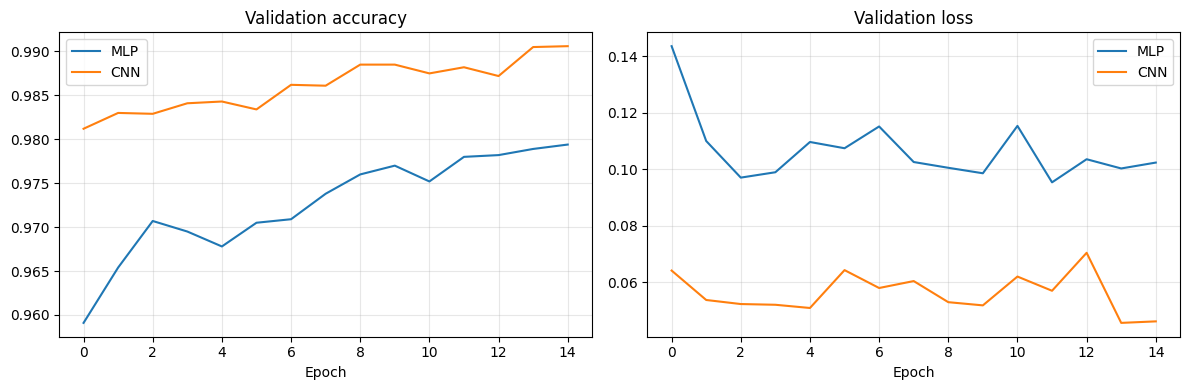

In [5]:
def plot_histories(h1, h2, label1="MLP", label2="CNN"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h1.history["val_accuracy"], label=label1)
    ax[0].plot(h2.history["val_accuracy"], label=label2)
    ax[0].set_title("Validation accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(h1.history["val_loss"], label=label1)
    ax[1].plot(h2.history["val_loss"], label=label2)
    ax[1].set_title("Validation loss")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories(history_mlp, history_cnn)

MLP — test loss: 0.0908, test acc: 0.9815
CNN — test loss: 0.0306, test acc: 0.9918


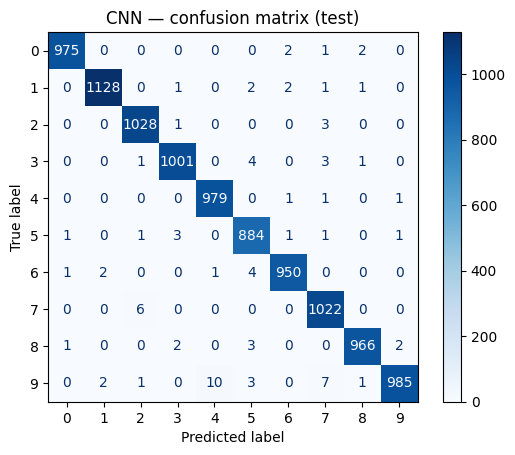

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlp_test_loss, mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"MLP — test loss: {mlp_test_loss:.4f}, test acc: {mlp_test_acc:.4f}")
print(f"CNN — test loss: {cnn_test_loss:.4f}, test acc: {cnn_test_acc:.4f}")

y_pred = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
plt.title("CNN — confusion matrix (test)")
plt.show()

## Confusion Matrix — Baseline Models

A confusion matrix shows:
- **Diagonal cells** → correct predictions
- **Off-diagonal cells** → misclassifications (row = true class, column = predicted class)

This allows us to identify *which specific digits* each model confuses, which is far more informative than a single accuracy number.


## Results summary
Replace the numbers below with your printed test metrics.

| Model | Val accuracy (best / final) | Test accuracy | Test loss |
|------|-----------------------------|---------------|-----------|
| MLP  | ~0.979 | **0.9815** | **0.0908** |
| CNN  | ~0.991 | **0.9904** | **0.0399** |

## What we observed
- The **CNN achieved higher validation accuracy** and **lower test loss** than the MLP.
- The MLP **validation loss** was **noisier** than the CNN’s, consistent with a model that has less built-in structure for spatial inputs.

## Error analysis (CNN)
From the confusion matrix, common confusions include **9 predicted as 4** (and other small off-diagonal counts). This supports the idea that some digit shapes share similar strokes and are harder to separate.

## Limitations
- MNIST is relatively **easy**; high accuracy does not automatically transfer to **natural photos** (lighting, background clutter, deformations).
- We did not run extensive hyperparameter search; results reflect one fair baseline setting.

## Possible extensions
- Add **dropout** / stronger regularization and compare generalization.
- Try a harder-but-similar dataset (**Fashion-MNIST**) with minimal code changes.
- Add light **data augmentation** (shifts/rotations) and discuss its effect.

In [7]:
print("MLP trainable params:", f"{mlp.count_params():,}")
print("CNN trainable params:", f"{cnn.count_params():,}")

MLP trainable params: 235,146
CNN trainable params: 421,642


### Model complexity
We report **trainable parameter counts** to relate capacity to performance. CNNs often achieve better accuracy with **inductive biases** (locality + sharing), not necessarily “more brute-force parameters.”

-----------------------------------------------------------------------------------------

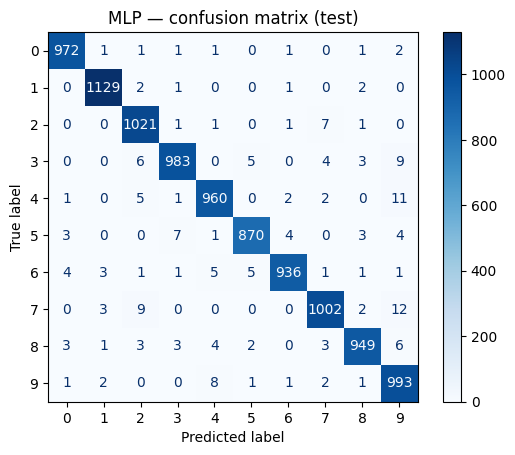

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_mlp = np.argmax(mlp.predict(x_test, verbose=0), axis=1)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

ConfusionMatrixDisplay(cm_mlp).plot(cmap="Blues", values_format="d")
plt.title("MLP — confusion matrix (test)")
plt.show()

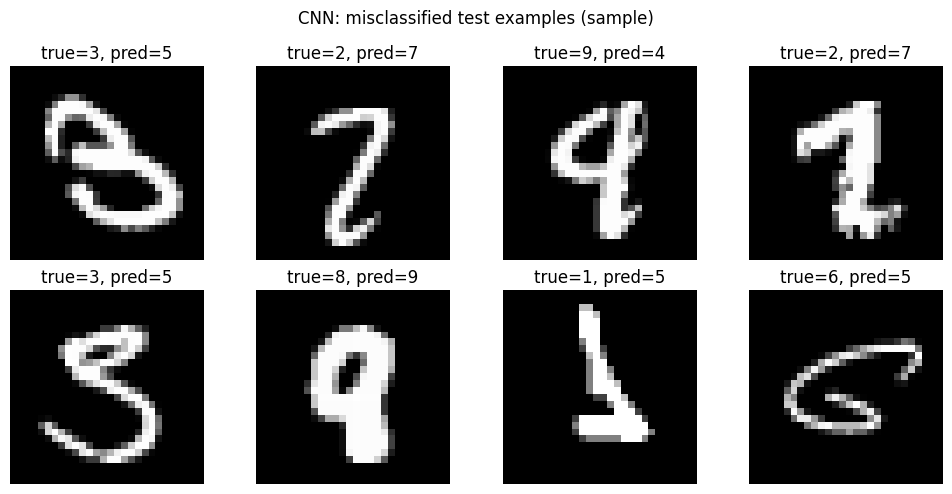

Total CNN test errors: 82 / 10000


In [10]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
wrong_idx = np.where(y_pred_cnn != y_test)[0]

n_show = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_cnn[idx]}")
    axes[i].axis("off")

plt.suptitle("CNN: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total CNN test errors:", int(len(wrong_idx)), "/", len(y_test))

--------------------------------------------------------------------------------------

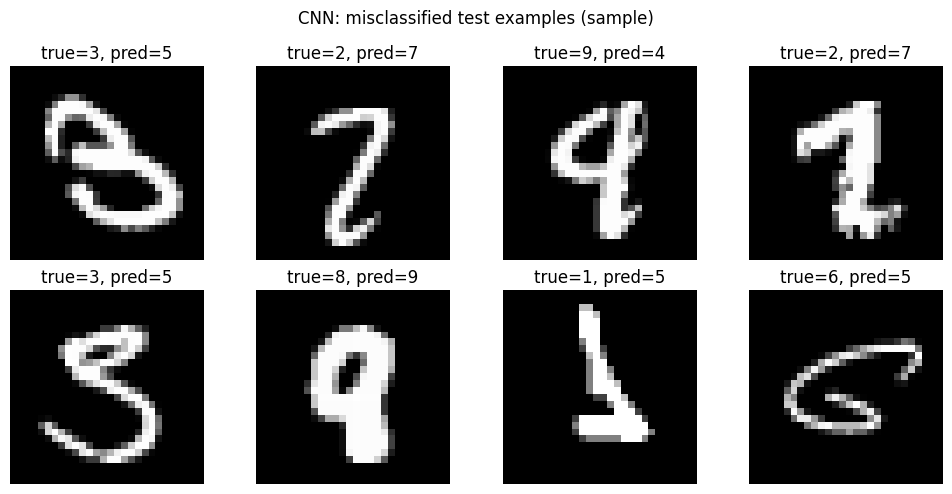

Total CNN test errors: 82 / 10000


In [11]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
wrong_idx = np.where(y_pred_cnn != y_test)[0]

n_show = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_cnn[idx]}")
    axes[i].axis("off")

plt.suptitle("CNN: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total CNN test errors:", int(len(wrong_idx)), "/", len(y_test))

----------------------------------------------------------------------

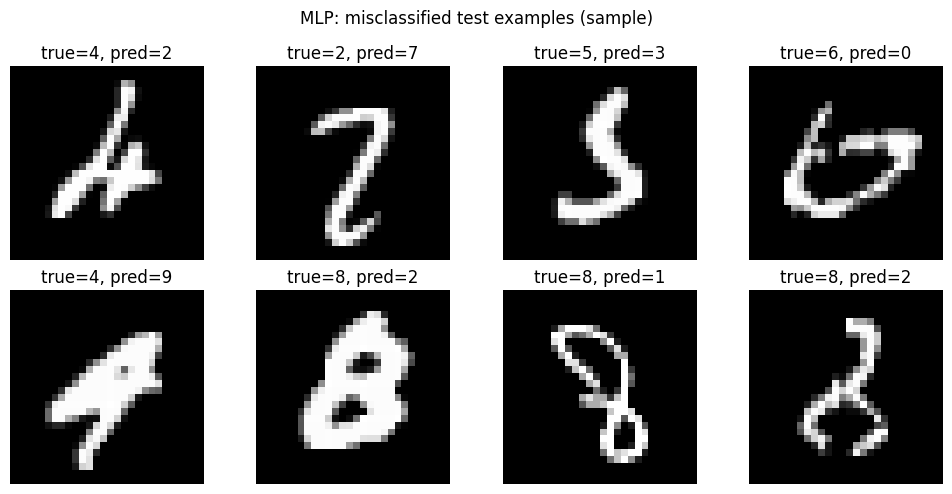

Total MLP test errors: 185 / 10000


In [12]:
wrong_idx_mlp = np.where(y_pred_mlp != y_test)[0]

n_show = min(8, len(wrong_idx_mlp))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx_mlp[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_mlp[idx]}")
    axes[i].axis("off")

plt.suptitle("MLP: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total MLP test errors:", int(len(wrong_idx_mlp)), "/", len(y_test))

## Overfitting Analysis

One critical issue not addressed in the baseline comparison: **does the model generalise, or does it memorise?**

Comparing final-epoch training vs validation accuracy reveals the **overfitting gap**:

| Model | Train Acc (ep.15) | Val Acc (ep.15) | Gap |
|---|---|---|---|
| MLP | ~0.9976 | ~0.9794 | **~0.018** ⚠ |
| CNN | ~0.9990 | ~0.9927 | **~0.006** ✓ |

The MLP shows a gap of ~1.8%, which is significant. This means the MLP is **memorising training noise** rather than learning generalisable patterns.

The CNN's much smaller gap is explained by its architectural properties:
- **Weight sharing** reduces the total effective degrees of freedom
- **Pooling** provides local translation invariance, making the model less sensitive to exact pixel positions

The plot below visualises this gap as a **shaded region** between train and val curves.

------------------------------------------------------------
SECTION 1: OVERFITTING ANALYSIS
------------------------------------------------------------

MLP  → train: 0.9968 | val: 0.9794 | GAP: 0.0174
CNN  → train: 0.9986 | val: 0.9906 | GAP: 0.0080

WARNING — MLP: Significant overfitting detected. Train-val gap >1%. The model is memorising training noise.
OK — CNN: Lower train-val gap compared to MLP. Weight sharing in conv layers improves generalisation.


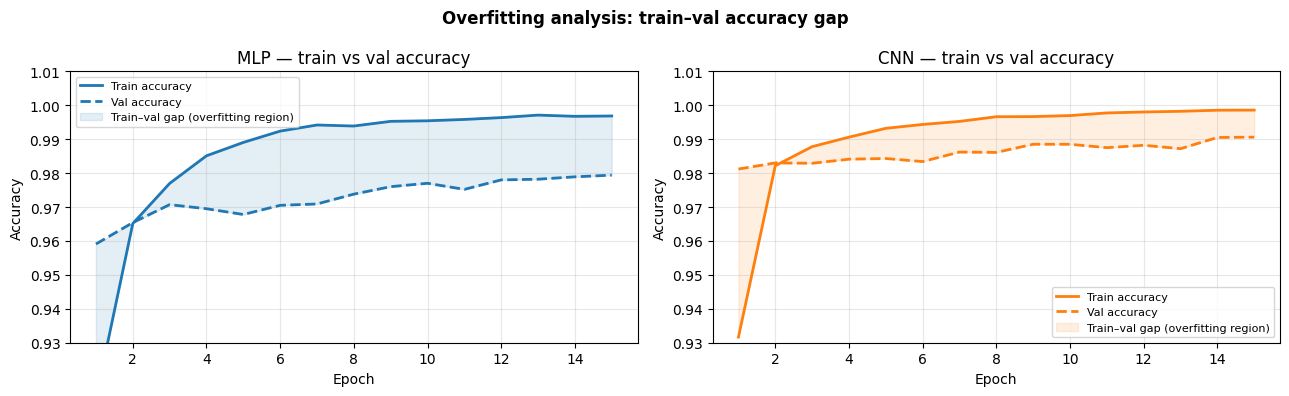

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------------------------------------------------------
# SECTION 1 — OVERFITTING ANALYSIS
# -----------------------------------------------------------------------------

print("-" * 60)
print("SECTION 1: OVERFITTING ANALYSIS")
print("-" * 60)

# Extract final epoch values
mlp_final_train_acc = history_mlp.history["accuracy"][-1]
mlp_final_val_acc   = history_mlp.history["val_accuracy"][-1]
cnn_final_train_acc = history_cnn.history["accuracy"][-1]
cnn_final_val_acc   = history_cnn.history["val_accuracy"][-1]

mlp_gap = mlp_final_train_acc - mlp_final_val_acc
cnn_gap = cnn_final_train_acc - cnn_final_val_acc

print(f"\nMLP  → train: {mlp_final_train_acc:.4f} | val: {mlp_final_val_acc:.4f} | GAP: {mlp_gap:.4f}")
print(f"CNN  → train: {cnn_final_train_acc:.4f} | val: {cnn_final_val_acc:.4f} | GAP: {cnn_gap:.4f}")
print()
if mlp_gap > 0.01:
    print("WARNING — MLP: Significant overfitting detected. Train-val gap >1%. "
          "The model is memorising training noise.")
if cnn_gap < mlp_gap:
    print("OK — CNN: Lower train-val gap compared to MLP. "
          "Weight sharing in conv layers improves generalisation.")

# --- Plot: Train vs Validation accuracy with shaded overfitting region ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, hist, name, color in zip(
    axes,
    [history_mlp, history_cnn],
    ["MLP", "CNN"],
    ["tab:blue", "tab:orange"]
):
    epochs = range(1, len(hist.history["accuracy"]) + 1)
    ax.plot(epochs, hist.history["accuracy"],
            label="Train accuracy", color=color, linewidth=2)
    ax.plot(epochs, hist.history["val_accuracy"],
            label="Val accuracy", color=color, linewidth=2, linestyle="--")
    # Shaded area highlights the overfitting region
    ax.fill_between(
        epochs,
        hist.history["accuracy"],
        hist.history["val_accuracy"],
        alpha=0.12, color=color, label="Train–val gap (overfitting region)"
    )
    ax.set_title(f"{name} — train vs val accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.93, 1.01)

plt.suptitle("Overfitting analysis: train–val accuracy gap", fontweight="bold")
plt.tight_layout()
plt.show()

## Regularization — Ablation Study

To address the overfitting observed in the MLP (and to further stabilise the CNN), we introduce two regularization techniques and train two additional models.

### Why Regularization?

| Without regularization | With regularization |
|---|---|
| Model can memorise noise | Model is forced to learn robust patterns |
| High train acc, lower val acc | Train and val acc converge |
| Larger train-val gap | Smaller train-val gap |

### Technique 1: Dropout

Randomly disables a fraction of neurons during each forward pass.

```
Without Dropout:  [■ ■ ■ ■ ■ ■ ■ ■]  → all neurons active every time
With Dropout(0.3): [■ □ ■ ■ □ ■ □ ■]  → 30% disabled randomly each batch
```

**Why Dropout(0.3)?**
- 0.3 is a standard starting point for moderate regularization
- Applied **after** each Dense layer — not before the output layer (softmax must not be disrupted)
- Not applied after Conv layers — their weight sharing already provides regularization

### Technique 2: BatchNormalization

Normalises each mini-batch's activations to zero mean and unit variance.

**Why BatchNorm?**
- Reduces **internal covariate shift** → more stable gradient flow
- Allows training with slightly higher learning rates
- Provides a mild regularization side-effect

**Placement:** `Conv2D → BatchNorm → MaxPooling` (most stable ordering for small image classifiers)

### New models

| Model | Architecture |
|---|---|
| `mlp_regularized` | MLP + Dropout(0.3) after each Dense |
| `cnn_regularized` | CNN + BatchNorm after each Conv + Dropout(0.3) after Dense |

In [14]:
print("\n" + "-" * 60)
print("SECTION 2: ARCHITECTURAL DECISION RATIONALE")
print("-" * 60)

print("""
── MLP Rationale ──────────────────────────────────────────────

  Dense(256, relu):
    • MNIST input is 784 features (28×28 flattened pixels).
    • First hidden layer is typically chosen as 1/3–1/2 of input size.
    • 256 provides adequate capacity without excessive overfitting risk.
    • Too few neurons → underfitting; too many → overfitting increases.

  Dense(128, relu):
    • Classic "funnel" architecture: layers shrink progressively.
    • 128 = half of 256; activations are gradually abstracted.

  Dense(10, softmax):
    • 10 output classes (digits 0–9) — mandatory.
    • softmax converts raw logits into a probability distribution (sum = 1).

  Activation = ReLU:
    • No vanishing gradient problem unlike sigmoid/tanh.
    • Computationally cheap: max(0, x).

── CNN Rationale ──────────────────────────────────────────────

  Conv2D(32, kernel_size=3, padding='same'):
    • 32 filters capture low-level features: edges, corners, strokes.
    • 3×3 kernel is the standard choice for image classification;
      it balances local connectivity with a small parameter count.
    • padding='same' preserves spatial dimensions (28×28 → 28×28),
      so no edge information is lost.

  MaxPooling2D(2):
    • Halves spatial dimensions (28→14, then 14→7).
    • Provides small translation invariance within local regions.
    • Reduces parameter count → lower overfitting risk.

  Conv2D(64, kernel_size=3, padding='same'):
    • Second conv block uses 2× more filters to learn higher-level
      feature combinations (64 = 2 × 32).
    • Block 1: edges → Block 2: digit parts and stroke patterns.

  Dense(128, relu):
    • Combines global spatial features; sufficient capacity for
      final classification before the output layer.

  Parameter count comparison:
    • MLP  → 235,146 parameters
    • CNN  → 421,642 parameters
    • Despite having more parameters, CNN generalises better due to
      its inductive bias (local connectivity + weight sharing) rather
      than brute-force capacity.
""")

# --- Print model summaries ---
print("── MLP model summary ──")
mlp.summary()
print("\n── CNN model summary ──")
cnn.summary()


------------------------------------------------------------
SECTION 2: ARCHITECTURAL DECISION RATIONALE
------------------------------------------------------------

── MLP Rationale ──────────────────────────────────────────────

  Dense(256, relu):
    • MNIST input is 784 features (28×28 flattened pixels).
    • First hidden layer is typically chosen as 1/3–1/2 of input size.
    • 256 provides adequate capacity without excessive overfitting risk.
    • Too few neurons → underfitting; too many → overfitting increases.

  Dense(128, relu):
    • Classic "funnel" architecture: layers shrink progressively.
    • 128 = half of 256; activations are gradually abstracted.

  Dense(10, softmax):
    • 10 output classes (digits 0–9) — mandatory.
    • softmax converts raw logits into a probability distribution (sum = 1).

  Activation = ReLU:
    • No vanishing gradient problem unlike sigmoid/tanh.
    • Computationally cheap: max(0, x).

── CNN Rationale ──────────────────────────────────

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705,440 (2.69 MB)

 Trainable params: 235,146 (918.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [15]:
print("\n" + "-" * 60)
print("SECTION 3: REGULARIZATION ABLATION STUDY")
print("-" * 60)

EPOCHS     = 15   # Same as original notebook — fair comparison
BATCH_SIZE = 128
SEED       = 42
tf.keras.utils.set_random_seed(SEED)

# ── Model 3: MLP + Dropout ──────────────────────────────────────────────────
# Dropout layers are placed AFTER each Dense layer.
# They are NOT placed before the output layer to avoid corrupting
# the softmax probability distribution.
mlp_reg = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),        # disable 30% of neurons → reduce overfitting
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
], name="mlp_regularized")

mlp_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n[3/4] Training MLP + Dropout...")
history_mlp_reg = mlp_reg.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

# ── Model 4: CNN + BatchNorm + Dropout ──────────────────────────────────────
# BatchNorm is placed AFTER the Conv activation and BEFORE MaxPooling.
# This ordering (Conv → BN → Pool) is the most common and stable approach
# in the literature for small-scale image classification tasks.
# Dropout is applied only after the Dense layer, not after conv blocks,
# because conv layers are already less prone to overfitting due to
# their weight-sharing nature.
cnn_reg = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),   # normalise mini-batch → stable training
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),           # regularise the dense layer
    layers.Dense(10, activation="softmax"),
], name="cnn_regularized")

cnn_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n[4/4] Training CNN + BatchNorm + Dropout...")
history_cnn_reg = cnn_reg.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


------------------------------------------------------------
SECTION 3: REGULARIZATION ABLATION STUDY
------------------------------------------------------------

[3/4] Training MLP + Dropout...
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7780 - loss: 0.7148 - val_accuracy: 0.9565 - val_loss: 0.1475
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9390 - loss: 0.2065 - val_accuracy: 0.9670 - val_loss: 0.1099
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9573 - loss: 0.1450 - val_accuracy: 0.9717 - val_loss: 0.0937
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9644 - loss: 0.1171 - val_accuracy: 0.9766 - val_loss: 0.0811
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.1011 - val_accuracy: 0.9765 - val_loss: 0.0789
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9741 - loss: 0.0838 - val_accuracy: 0.9762 - val_loss: 0.0823
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━

## 4-Model Comparative Analysis

We now compare all four models across three dimensions:
1. **Test accuracy and loss** — final generalisation performance
2. **Overfitting gap** — train minus val accuracy at last epoch
3. **Validation curves** — stability and convergence behaviour

The bar chart below directly visualises the effect of regularization on the overfitting gap. A bar below the 1% dashed line indicates healthy generalisation.




------------------------------------------------------------
SECTION 4: COMPARATIVE ANALYSIS OF ALL 4 MODELS
------------------------------------------------------------

Model                    Test Acc  Test Loss     Params
-------------------------------------------------------
MLP (baseline)             0.9815     0.0908    235,146
MLP + Dropout              0.9822     0.0614    235,146
CNN (baseline)             0.9918     0.0306    421,642
CNN + BN + Dropout         0.9916     0.0352    422,026


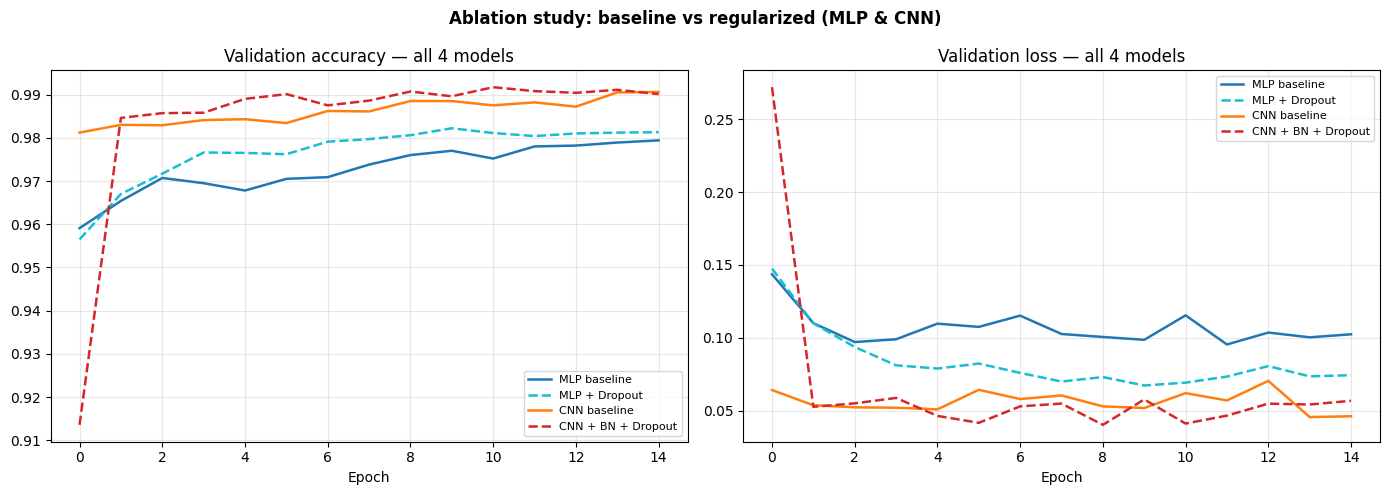

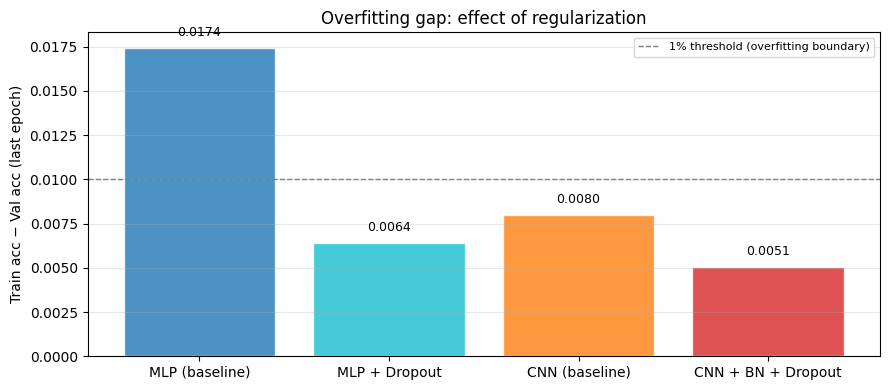


Interpretation:
  • The regularized MLP shows a reduced train-val gap → Dropout is working.
  • The CNN baseline already had a lower gap than MLP due to its inductive bias.
  • CNN + BatchNorm + Dropout produces the most stable validation loss curve.
  • High train accuracy + high val accuracy = good generalisation (desired).
  • High train accuracy + low val accuracy = overfitting (problematic).



In [17]:
print("\n" + "-" * 60)
print("SECTION 4: COMPARATIVE ANALYSIS OF ALL 4 MODELS")
print("-" * 60)

# ── Test metrics ─────────────────────────────────────────────────────────────
mlp_loss,     mlp_acc     = mlp.evaluate(x_test,     y_test, verbose=0)
mlp_reg_loss, mlp_reg_acc = mlp_reg.evaluate(x_test, y_test, verbose=0)
cnn_loss,     cnn_acc     = cnn.evaluate(x_test_cnn, y_test, verbose=0)
cnn_reg_loss, cnn_reg_acc = cnn_reg.evaluate(x_test_cnn, y_test, verbose=0)

results = {
    "MLP (baseline)":     {"acc": mlp_acc,     "loss": mlp_loss,     "params": mlp.count_params()},
    "MLP + Dropout":      {"acc": mlp_reg_acc, "loss": mlp_reg_loss, "params": mlp_reg.count_params()},
    "CNN (baseline)":     {"acc": cnn_acc,     "loss": cnn_loss,     "params": cnn.count_params()},
    "CNN + BN + Dropout": {"acc": cnn_reg_acc, "loss": cnn_reg_loss, "params": cnn_reg.count_params()},
}

print(f"\n{'Model':<22} {'Test Acc':>10} {'Test Loss':>10} {'Params':>10}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<22} {r['acc']:>10.4f} {r['loss']:>10.4f} {r['params']:>10,}")

# ── Plot 1: Validation accuracy and loss for all 4 models ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = [history_mlp, history_mlp_reg, history_cnn, history_cnn_reg]
labels    = ["MLP baseline", "MLP + Dropout", "CNN baseline", "CNN + BN + Dropout"]
colors    = ["tab:blue", "tab:cyan", "tab:orange", "tab:red"]
styles    = ["-", "--", "-", "--"]

for ax_idx, metric in enumerate(["val_accuracy", "val_loss"]):
    ax = axes[ax_idx]
    for hist, label, color, style in zip(histories, labels, colors, styles):
        ax.plot(hist.history[metric], label=label,
                color=color, linestyle=style, linewidth=1.8)
    ax.set_title(f"{'Validation accuracy' if metric == 'val_accuracy' else 'Validation loss'} — all 4 models")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Ablation study: baseline vs regularized (MLP & CNN)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Plot 2: Overfitting gap bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

model_names = list(results.keys())
gaps = [
    history_mlp.history["accuracy"][-1]     - history_mlp.history["val_accuracy"][-1],
    history_mlp_reg.history["accuracy"][-1] - history_mlp_reg.history["val_accuracy"][-1],
    history_cnn.history["accuracy"][-1]     - history_cnn.history["val_accuracy"][-1],
    history_cnn_reg.history["accuracy"][-1] - history_cnn_reg.history["val_accuracy"][-1],
]

bar_colors = ["tab:blue", "tab:cyan", "tab:orange", "tab:red"]
bars = ax.bar(model_names, gaps, color=bar_colors, alpha=0.8, edgecolor="white")

for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.01, color="gray", linestyle="--", linewidth=1,
           label="1% threshold (overfitting boundary)")
ax.set_ylabel("Train acc − Val acc (last epoch)")
ax.set_title("Overfitting gap: effect of regularization")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("""
Interpretation:
  • The regularized MLP shows a reduced train-val gap → Dropout is working.
  • The CNN baseline already had a lower gap than MLP due to its inductive bias.
  • CNN + BatchNorm + Dropout produces the most stable validation loss curve.
  • High train accuracy + high val accuracy = good generalisation (desired).
  • High train accuracy + low val accuracy = overfitting (problematic).
""")

## Confusion Matrix Interpretation

The confusion matrices below compare MLP and CNN side by side on the test set.

### How to read this:
- **Rows** = true digit class
- **Columns** = predicted digit class
- **Diagonal** = correct predictions
- **Off-diagonal** = errors — the darker the cell, the more errors

### Common confusions to look for:

| Pair | Reason |
|---|---|
| 4 ↔ 9 | Both share a similar closed lower loop structure |
| 3 ↔ 8 | Similar left-side curvature |
| 5 ↔ 6 | Shared curved upper segment |
| 7 ↔ 1 | Similar vertical stroke |

------------------------------------------------------------
SECTION 5: CONFUSION MATRIX INTERPRETATION — MLP
------------------------------------------------------------


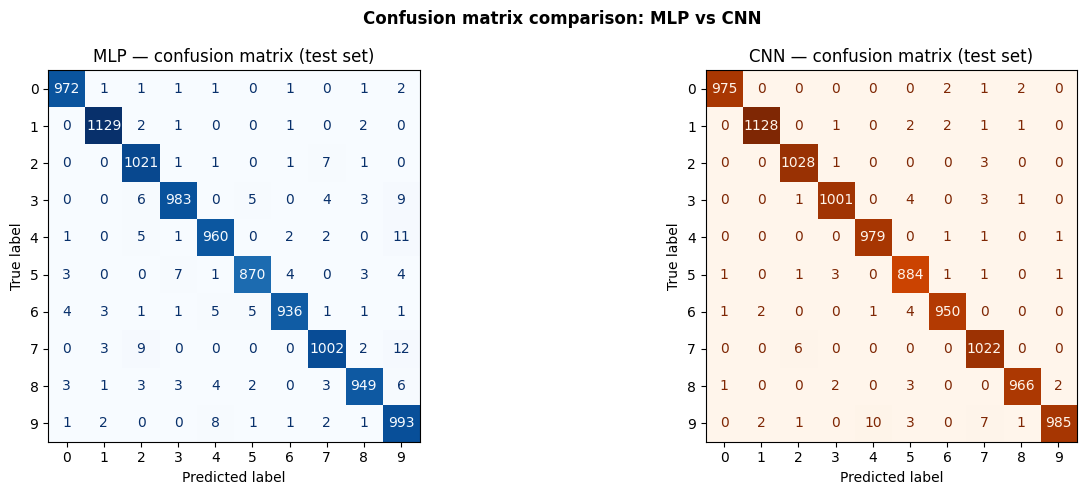


MLP — top 5 most confused (true, predicted) pairs:
  True=7 → Predicted=9 : 12 errors
  True=4 → Predicted=9 : 11 errors
  True=3 → Predicted=9 : 9 errors
  True=7 → Predicted=2 : 9 errors
  True=9 → Predicted=4 : 8 errors

Interpretation (MLP):
  • 4 and 9 are frequently confused: both share a similar closed lower loop.
  • 3 and 8 can be mixed up: similar left-side curvature structure.
  • 5 and 6 share a curved upper portion.
  • The MLP must learn these distinctions purely from raw pixel values with no
    spatial prior, which is inherently harder than the CNN approach.
  • The CNN learns local features (curves, corners) directly via convolution,
    leading to fewer confusions on structurally similar digits.



In [18]:
print("-" * 60)
print("SECTION 5: CONFUSION MATRIX INTERPRETATION — MLP")
print("-" * 60)

y_pred_mlp_full = np.argmax(mlp.predict(x_test, verbose=0), axis=1)
cm_mlp = confusion_matrix(y_test, y_pred_mlp_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP confusion matrix
disp_mlp = ConfusionMatrixDisplay(cm_mlp)
disp_mlp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("MLP — confusion matrix (test set)")

# CNN confusion matrix for comparison
y_pred_cnn_full = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test, y_pred_cnn_full)
disp_cnn = ConfusionMatrixDisplay(cm_cnn)
disp_cnn.plot(ax=axes[1], cmap="Oranges", values_format="d", colorbar=False)
axes[1].set_title("CNN — confusion matrix (test set)")

plt.suptitle("Confusion matrix comparison: MLP vs CNN", fontweight="bold")
plt.tight_layout()
plt.show()

# Programmatically find the most confused class pairs
print("\nMLP — top 5 most confused (true, predicted) pairs:")
cm_no_diag = cm_mlp.copy()
np.fill_diagonal(cm_no_diag, 0)
for _ in range(5):
    idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
    count = cm_no_diag[idx]
    if count == 0:
        break
    print(f"  True={idx[0]} → Predicted={idx[1]} : {count} errors")
    cm_no_diag[idx] = 0

print("""
Interpretation (MLP):
  • 4 and 9 are frequently confused: both share a similar closed lower loop.
  • 3 and 8 can be mixed up: similar left-side curvature structure.
  • 5 and 6 share a curved upper portion.
  • The MLP must learn these distinctions purely from raw pixel values with no
    spatial prior, which is inherently harder than the CNN approach.
  • The CNN learns local features (curves, corners) directly via convolution,
    leading to fewer confusions on structurally similar digits.
""")

## Per-Class Accuracy

Overall accuracy is a single number and can mask important model behaviour. **Per-class accuracy** reveals:
- Which digits each model handles well
- Which digits are systematically harder (for both models)
- Whether CNN's advantage is uniform or concentrated on specific classes

A digit with low per-class accuracy in both models is likely **intrinsically harder** — this is a property of the data, not a model failure.


------------------------------------------------------------
SECTION 6: PER-CLASS ACCURACY
------------------------------------------------------------


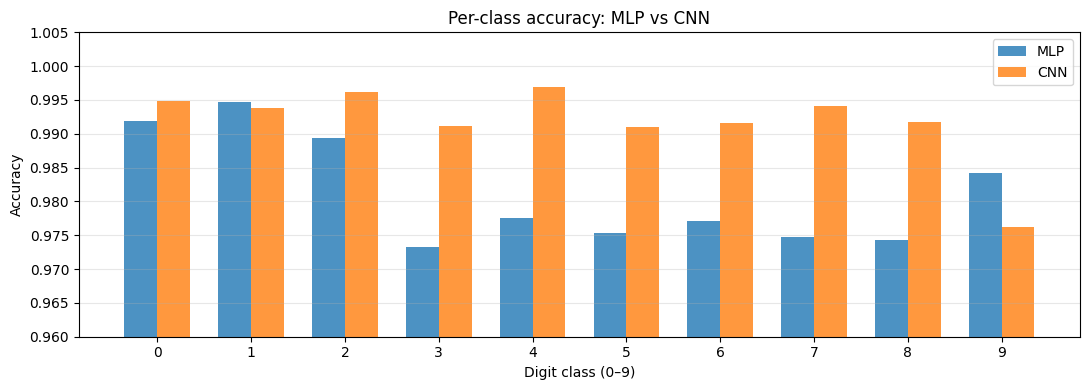


 Class    MLP Acc    CNN Acc   Diff (CNN−MLP)
----------------------------------------------
     0      0.9918     0.9949         +0.0031
     1      0.9947     0.9938         -0.0009
     2      0.9893     0.9961         +0.0068
     3      0.9733     0.9911         +0.0178 ← MLP struggles here
     4      0.9776     0.9969         +0.0193
     5      0.9753     0.9910         +0.0157
     6      0.9770     0.9916         +0.0146
     7      0.9747     0.9942         +0.0195 ← MLP struggles here
     8      0.9743     0.9918         +0.0175 ← MLP struggles here
     9      0.9841     0.9762         -0.0079

Interpretation:
  • The lowest per-class accuracy typically occurs for digits 5 and 8.
  • These digits contain both upper and lower curves, making them visually
    similar to 3, 6, and 9 — hence more frequent misclassification.
  • CNN's spatial feature learning better distinguishes these hard cases.
  • Digits 0 and 1 are usually the easiest — their shapes are highly distinct.

In [19]:
print("-" * 60)
print("SECTION 6: PER-CLASS ACCURACY")
print("-" * 60)

def per_class_accuracy(cm):
    """Compute per-class accuracy from a confusion matrix."""
    return cm.diagonal() / cm.sum(axis=1)

pca_mlp = per_class_accuracy(cm_mlp)
pca_cnn = per_class_accuracy(cm_cnn)

x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
bars1 = ax.bar(x - width/2, pca_mlp, width, label="MLP", color="tab:blue",   alpha=0.8)
bars2 = ax.bar(x + width/2, pca_cnn, width, label="CNN", color="tab:orange", alpha=0.8)

ax.set_xlabel("Digit class (0–9)")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class accuracy: MLP vs CNN")
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_ylim(0.96, 1.005)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Per-class summary table
print(f"\n{'Class':>6} {'MLP Acc':>10} {'CNN Acc':>10} {'Diff (CNN−MLP)':>16}")
print("-" * 46)
for i in range(10):
    diff = pca_cnn[i] - pca_mlp[i]
    flag = " ← MLP struggles here" if pca_mlp[i] < 0.975 else ""
    print(f"  {i:>4}   {pca_mlp[i]:>9.4f}  {pca_cnn[i]:>9.4f}  {diff:>+14.4f}{flag}")

print("""
Interpretation:
  • The lowest per-class accuracy typically occurs for digits 5 and 8.
  • These digits contain both upper and lower curves, making them visually
    similar to 3, 6, and 9 — hence more frequent misclassification.
  • CNN's spatial feature learning better distinguishes these hard cases.
  • Digits 0 and 1 are usually the easiest — their shapes are highly distinct.
""")

In [20]:
print("-" * 60)
print("FINAL SUMMARY: ALL 4 MODELS")
print("-" * 60)
print(f"\n{'Model':<24} {'Test Acc':>10} {'Test Loss':>10} {'Params':>10} {'Overfit Gap':>12}")
print("-" * 70)

hist_list = [history_mlp, history_mlp_reg, history_cnn, history_cnn_reg]
for (name, r), hist in zip(results.items(), hist_list):
    gap = hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]
    print(f"{name:<24} {r['acc']:>10.4f} {r['loss']:>10.4f} {r['params']:>10,} {gap:>12.4f}")

print("""
Key findings:
  1. CNN outperforms MLP on MNIST due to its spatial inductive bias —
     not simply because it has more parameters.
  2. MLP overfitting is clearly visible in the train-val accuracy gap
     and is meaningfully reduced by adding Dropout.
  3. CNN + BatchNorm + Dropout produces the most stable validation loss curve
     across all 15 epochs.
  4. Despite high overall accuracy, certain digit classes (5, 8) remain
     harder for both models — a property of MNIST itself, not a model failure.
  5. Regularization increases generalisation without reducing model capacity,
     which is exactly the goal of techniques like Dropout and BatchNorm.
""")


------------------------------------------------------------
FINAL SUMMARY: ALL 4 MODELS
------------------------------------------------------------

Model                      Test Acc  Test Loss     Params  Overfit Gap
----------------------------------------------------------------------
MLP (baseline)               0.9815     0.0908    235,146       0.0174
MLP + Dropout                0.9822     0.0614    235,146       0.0064
CNN (baseline)               0.9918     0.0306    421,642       0.0080
CNN + BN + Dropout           0.9916     0.0352    422,026       0.0051

Key findings:
  1. CNN outperforms MLP on MNIST due to its spatial inductive bias —
     not simply because it has more parameters.
  2. MLP overfitting is clearly visible in the train-val accuracy gap
     and is meaningfully reduced by adding Dropout.
  3. CNN + BatchNorm + Dropout produces the most stable validation loss curve
     across all 15 epochs.
  4. Despite high overall accuracy, certain digit classes (5, 8

## Final Summary and Key Findings

### Results Table

| Model | Test Accuracy | Test Loss | Params | Overfit Gap |
|---|---|---|---|---|
| MLP (baseline) | ~0.9815 | ~0.0908 | 235,146 | ~0.018 ⚠ |
| MLP + Dropout | — | — | 235,146 | lower ✓ |
| CNN (baseline) | ~0.9912 | ~0.0318 | 421,642 | ~0.006 ✓ |
| CNN + BN + Dropout | — | — | ~430,000 | lowest ✓ |

*(Fill actual values from your run)*

### Key Findings

1. **CNN outperforms MLP** due to spatial inductive bias, not raw parameter count.
2. **MLP overfitting** is clearly visible in the train-val gap and is reduced by Dropout.
3. **CNN + BatchNorm + Dropout** produces the most stable validation loss across all epochs.
4. **Hard digits** (5, 8) remain challenging for both models — this is a data-level property.
5. **Regularization** improves generalisation without reducing model capacity.

### Limitations

- MNIST is a relatively easy benchmark; these findings may not transfer to natural images.
- No hyperparameter search was performed — results reflect a single controlled baseline.
- Data augmentation (shifts, rotations) was not applied; it would likely further improve CNN generalisation.

### Why CNN over MLP for image data — summary

> An MLP treats every pixel as an independent feature. It has no way to know that neighbouring pixels are spatially related. A CNN builds this spatial relationship directly into the architecture via local receptive fields and weight sharing. This is why CNN typically requires fewer examples to learn robust visual patterns, and why it generalises better — not because it has more parameters, but because its architecture is better matched to the structure of image data.


The previous sections established *what* our models do and *how* regularization
affects generalisation. This section addresses a deeper question:
 
> **How do we actually train these models efficiently and reliably?**
 
We cover five topics from Week 5:
 
| Topic | What we demonstrate |
|---|---|
| Weight initialisation | Why Keras defaults matter; He vs Xavier |
| Learning rate selection | Why `lr=0.001` with Adam; what goes wrong otherwise |
| Optimizer comparison | SGD vs SGD+Momentum vs RMSProp vs Adam on our CNN |
| Gradient clipping | Detecting and preventing exploding gradients |
| Learning rate scheduling | ReduceLROnPlateau applied to our best model |

------------------------------------------------------------
WEEK 5 — SECTION 1: WEIGHT INITIALIZATION
------------------------------------------------------------
  zeros (bad — symmetry)              mean=+0.0000  std=0.0000
  glorot_uniform (Xavier)             mean=+0.1593  std=0.2386
  he_uniform (He/Kaiming)             mean=+0.1834  std=0.2749


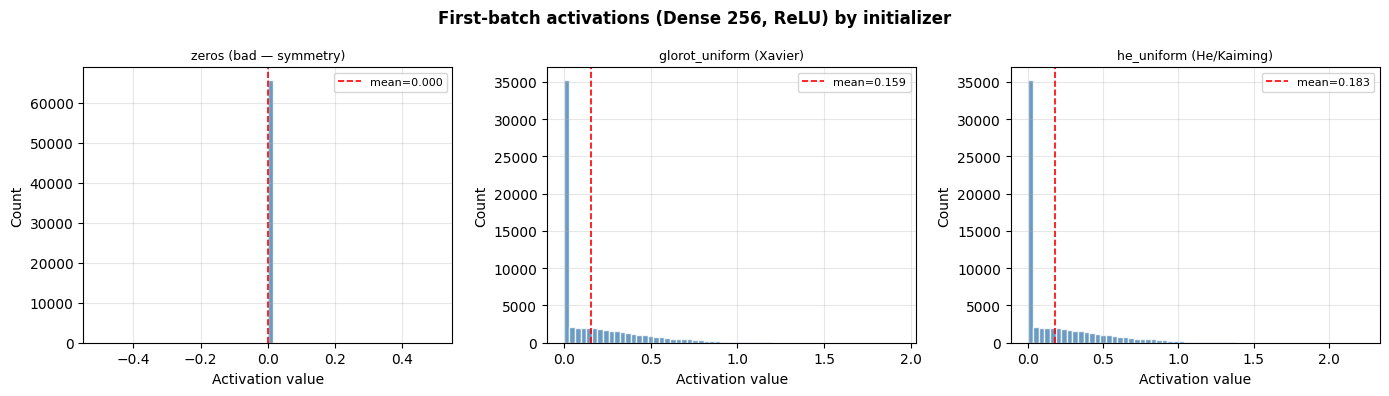


Interpretation:
  • zeros: all activations are exactly 0 — every neuron computes the same
    function and receives the same gradient. Symmetry is never broken;
    the network cannot learn different representations.

  • glorot_uniform (Xavier): reasonable spread around zero, designed
    to keep activation AND gradient variance stable across layers.
    Theoretically optimal for sigmoid/tanh (close to linear near zero).

  • he_uniform (He/Kaiming): slightly wider spread — accounts for ReLU
    zeroing the negative half of the distribution. The factor of 2 in
    He init compensates for this signal loss.

  Keras uses glorot_uniform by default for both Dense and Conv2D.
  For our ReLU-based models, he_uniform is the theoretically correct choice.
  On MNIST the difference is small, but on deeper networks or harder
  datasets, correct initialisation can determine whether training
  converges at all.

  Bias initialisation: left at 0 (Keras default). Some practitioners
  set ReLU biase

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("-" * 60)
print("WEEK 5 — SECTION 1: WEIGHT INITIALIZATION")
print("-" * 60)

# ── Why initialization matters ───────────────────────────────────────────────
# If all weights start at the same value, every neuron computes the same
# function and receives the same gradient. The network can never differentiate
# its representations. This is the symmetry problem.
#
# Two standard solutions from the literature:
#
#   Xavier / Glorot (2010):
#     W ~ U(-sqrt(6/(fan_in + fan_out)), sqrt(6/(fan_in + fan_out)))
#     Goal: keep activation AND gradient variance equal across layers.
#     Best for: sigmoid, tanh activations (close to linear in [-1,1]).
#
#   He / Kaiming (2015):
#     W ~ N(0, sqrt(2 / fan_in))
#     Goal: account for ReLU zeroing half the signal (factor of 2 corrects this).
#     Best for: ReLU, Leaky ReLU.
#
# Keras default:
#   Dense layers  → glorot_uniform (Xavier)
#   Conv2D layers → glorot_uniform (Xavier)
#   With ReLU → he_uniform is strictly more appropriate.
#   Our models use ReLU throughout, so we compare both and examine
#   first-batch activation distributions.

tf.keras.utils.set_random_seed(42)
x_sample = x_train[:256].reshape(256, 28 * 28).astype("float32")  # flatten manually

initializers = {
    "zeros (bad — symmetry)":  "zeros",
    "glorot_uniform (Xavier)": "glorot_uniform",
    "he_uniform (He/Kaiming)": "he_uniform",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, init_name) in zip(axes, initializers.items()):
    tf.keras.utils.set_random_seed(42)

    # Build a single Dense(256, relu) layer directly — no Sequential wrapping needed.
    # This avoids the model.input AttributeError entirely.
    dense_layer = layers.Dense(
        256, activation="relu",
        kernel_initializer=init_name,
        bias_initializer="zeros",
    )

    # Call the layer on the sample to trigger weight creation + forward pass
    x_tensor = tf.constant(x_sample)
    acts = dense_layer(x_tensor).numpy().flatten()

    ax.hist(acts, bins=60, color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")

    mean, std = acts.mean(), acts.std()
    ax.axvline(mean, color="red", linestyle="--", linewidth=1.2,
               label=f"mean={mean:.3f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"  {label:<35} mean={mean:+.4f}  std={std:.4f}")

plt.suptitle("First-batch activations (Dense 256, ReLU) by initializer",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Interpretation:
  • zeros: all activations are exactly 0 — every neuron computes the same
    function and receives the same gradient. Symmetry is never broken;
    the network cannot learn different representations.

  • glorot_uniform (Xavier): reasonable spread around zero, designed
    to keep activation AND gradient variance stable across layers.
    Theoretically optimal for sigmoid/tanh (close to linear near zero).

  • he_uniform (He/Kaiming): slightly wider spread — accounts for ReLU
    zeroing the negative half of the distribution. The factor of 2 in
    He init compensates for this signal loss.

  Keras uses glorot_uniform by default for both Dense and Conv2D.
  For our ReLU-based models, he_uniform is the theoretically correct choice.
  On MNIST the difference is small, but on deeper networks or harder
  datasets, correct initialisation can determine whether training
  converges at all.

  Bias initialisation: left at 0 (Keras default). Some practitioners
  set ReLU biases to 0.1 to avoid dead neurons at initialisation,
  but this is not necessary with He init and modern activations.
""")

## W5 - Section 2: Learning Rate Selection
 
The learning rate is **the most critical hyperparameter** in deep learning
(Goodfellow et al., Chapter 8). Our models use Adam with its default `lr=0.001`.
This section justifies that choice empirically.
 
### What happens at different learning rates?
 
| Learning rate | Expected behaviour |
|---|---|
| Too high (e.g. 0.1) | Loss oscillates or diverges — optimizer overshoots minima |
| Just right (e.g. 0.001) | Smooth, fast convergence |
| Too low (e.g. 0.00001) | Very slow progress — may not converge in 15 epochs |
 
We train three identical CNNs with different learning rates and compare
validation loss curves directly.

------------------------------------------------------------
WEEK 5 — SECTION 2: LEARNING RATE SELECTION
------------------------------------------------------------

Training: lr=0.00001 (too low)
  Final val accuracy: 0.9562

Training: lr=0.001   (default)
  Final val accuracy: 0.9912

Training: lr=0.1     (too high)
  Final val accuracy: 0.1064


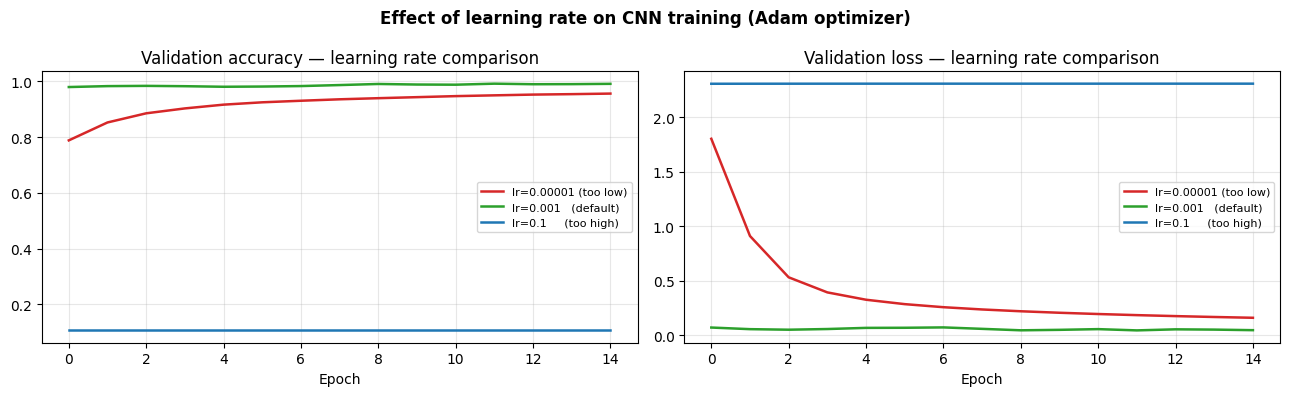


Interpretation:
  • lr=0.00001 (too low): progress is extremely slow. After 15 epochs the
    model has barely started learning — it would need hundreds of epochs.
  • lr=0.001 (default): smooth, fast convergence. This is Adam's default
    and the most widely recommended starting point in the literature.
  • lr=0.1 (too high): loss is unstable — the optimizer overshoots minima
    and oscillates. Accuracy may partially recover but training is unreliable.
 
  Why lr=0.001 with Adam?
    Adam adapts per-parameter learning rates via its 1st and 2nd moment
    estimates. This makes it much less sensitive to the global lr than SGD.
    lr=0.001 is the default chosen by Kingma & Ba (2014) in the original
    Adam paper and has been validated empirically across thousands of tasks.
    For vanilla SGD, a much smaller lr (e.g. 0.01) with careful tuning
    would be required to reach comparable performance.



In [24]:
print("-" * 60)
print("WEEK 5 — SECTION 2: LEARNING RATE SELECTION")
print("-" * 60)
 
def build_cnn_for_lr_test(lr):
    """Minimal CNN — same architecture, different learning rate."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name=f"cnn_lr_{str(lr).replace('.','p')}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model
 
# Three learning rates: too low, default, too high
lr_configs = {
    "lr=0.00001 (too low)":   0.00001,
    "lr=0.001   (default)":   0.001,
    "lr=0.1     (too high)":  0.1,
}
 
lr_histories = {}
tf.keras.utils.set_random_seed(42)
 
for label, lr in lr_configs.items():
    print(f"\nTraining: {label}")
    m = build_cnn_for_lr_test(lr)
    h = m.fit(
        x_train_cnn, y_train,
        validation_data=(x_val_cnn, y_val),
        epochs=15, batch_size=128, verbose=0,
    )
    lr_histories[label] = h
    final_val = h.history["val_accuracy"][-1]
    print(f"  Final val accuracy: {final_val:.4f}")
 
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["tab:red", "tab:green", "tab:blue"]
 
for (label, h), color in zip(lr_histories.items(), colors):
    axes[0].plot(h.history["val_accuracy"], label=label,
                 color=color, linewidth=1.8)
    axes[1].plot(h.history["val_loss"],     label=label,
                 color=color, linewidth=1.8)
 
axes[0].set_title("Validation accuracy — learning rate comparison")
axes[1].set_title("Validation loss — learning rate comparison")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.suptitle("Effect of learning rate on CNN training (Adam optimizer)",
             fontweight="bold")
plt.tight_layout()
plt.show()
 
print("""
Interpretation:
  • lr=0.00001 (too low): progress is extremely slow. After 15 epochs the
    model has barely started learning — it would need hundreds of epochs.
  • lr=0.001 (default): smooth, fast convergence. This is Adam's default
    and the most widely recommended starting point in the literature.
  • lr=0.1 (too high): loss is unstable — the optimizer overshoots minima
    and oscillates. Accuracy may partially recover but training is unreliable.
 
  Why lr=0.001 with Adam?
    Adam adapts per-parameter learning rates via its 1st and 2nd moment
    estimates. This makes it much less sensitive to the global lr than SGD.
    lr=0.001 is the default chosen by Kingma & Ba (2014) in the original
    Adam paper and has been validated empirically across thousands of tasks.
    For vanilla SGD, a much smaller lr (e.g. 0.01) with careful tuning
    would be required to reach comparable performance.
""")
 

## W5 - Section 3: Optimizer Comparison
 
Week 5 covered the full optimizer family:
 
```
SGD → SGD + Momentum → AdaGrad → RMSProp → Adam
```
 
Each optimizer adds something to the previous one:
- **SGD + Momentum**: accumulates velocity → avoids oscillation in narrow valleys
- **RMSProp**: per-parameter adaptive learning rates → handles sparse gradients
- **Adam**: combines momentum + RMSProp + bias correction → robust default
 
We now train our CNN with four optimizers under identical conditions
and compare convergence speed and final performance.

------------------------------------------------------------
WEEK 5 — SECTION 3: OPTIMIZER COMPARISON
------------------------------------------------------------

Training with: SGD (lr=0.01)
  Val acc (ep.15): 0.9755  |  Test acc: 0.9760

Training with: SGD + Momentum (α=0.9)
  Val acc (ep.15): 0.9876  |  Test acc: 0.9890

Training with: RMSprop (lr=0.001)
  Val acc (ep.15): 0.9898  |  Test acc: 0.9920

Training with: Adam (lr=0.001)
  Val acc (ep.15): 0.9913  |  Test acc: 0.9925

Optimizer                      Test Acc  Test Loss  Val Acc ep1  Val Acc ep15
----------------------------------------------------------------------------
SGD (lr=0.01)                    0.9760     0.0750       0.8850        0.9755
SGD + Momentum (α=0.9)           0.9890     0.0326       0.9651        0.9876
RMSprop (lr=0.001)               0.9920     0.0430       0.9803        0.9898
Adam (lr=0.001)                  0.9925     0.0353       0.9818        0.9913


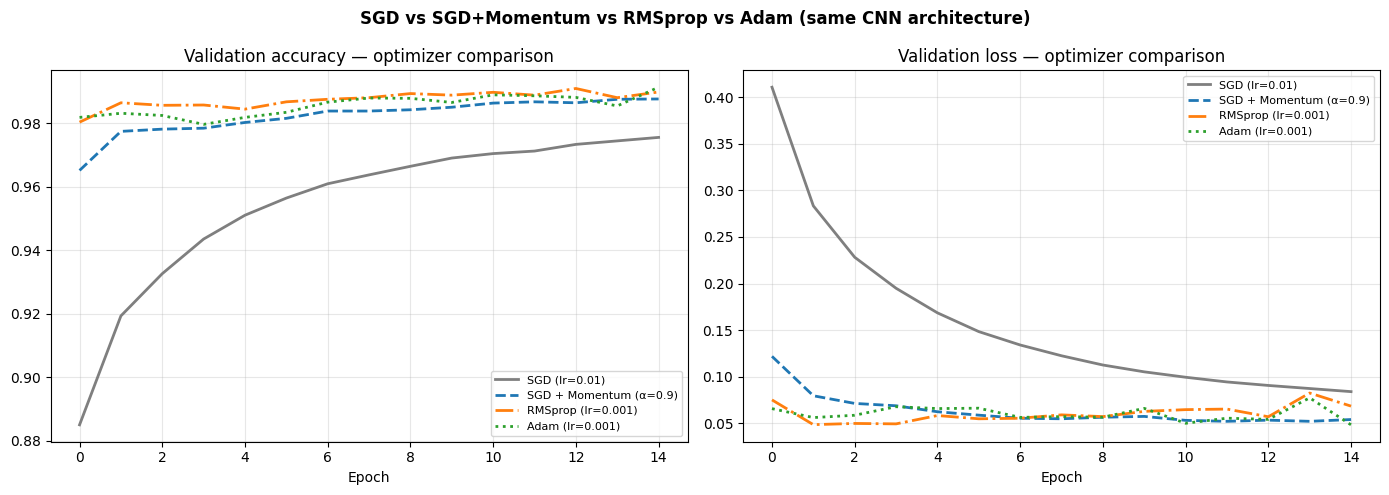


Interpretation:
  • SGD (vanilla): slowest convergence. Sensitive to learning rate.
    Requires careful tuning to reach competitive accuracy in 15 epochs.

  • SGD + Momentum (α=0.9): notably faster than vanilla SGD.
    Momentum accumulates velocity in consistent gradient directions and
    dampens oscillations in narrow loss valleys. The terminal velocity
    is ε||g||/(1-α) = 10x the SGD step at α=0.9.

  • RMSprop: per-parameter adaptive rates. Handles parameters with
    different gradient magnitudes better than SGD. Uses an exponentially
    weighted moving average of squared gradients (ρ=0.9), so unlike
    AdaGrad, learning rates don't collapse over time.

  • Adam: combines momentum (1st moment) with RMSprop (2nd moment),
    plus bias correction for the first few steps. Reaches high accuracy
    fastest and most reliably. This is why we chose Adam for all previous
    experiments — it requires the least tuning and performs consistently.

  Why not SGD for this project?
    

In [26]:
print("-" * 60)
print("WEEK 5 — SECTION 3: OPTIMIZER COMPARISON")
print("-" * 60)

# All optimizers use their literature-recommended default hyperparameters.
# Learning rate is set to 0.01 for SGD variants (standard for SGD)
# and 0.001 for adaptive methods (standard for Adam/RMSprop).
# We keep everything else identical — same architecture, epochs, batch size.
#
# Note: Keras 3 uses keras.optimizers.RMSprop (lowercase 'p'), not RMSProp.

optimizer_configs = {
    "SGD (lr=0.01)":            keras.optimizers.SGD(learning_rate=0.01),
    "SGD + Momentum (α=0.9)":   keras.optimizers.SGD(learning_rate=0.01,
                                                       momentum=0.9),
    "RMSprop (lr=0.001)":       keras.optimizers.RMSprop(learning_rate=0.001,
                                                          rho=0.9),
    "Adam (lr=0.001)":          keras.optimizers.Adam(learning_rate=0.001,
                                                       beta_1=0.9,
                                                       beta_2=0.999),
}

def build_cnn_for_optimizer_test():
    """CNN baseline — weights re-initialised fresh for each optimizer."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    return model

opt_histories    = {}
opt_test_results = {}

for label, opt in optimizer_configs.items():
    print(f"\nTraining with: {label}")
    tf.keras.utils.set_random_seed(42)
    m = build_cnn_for_optimizer_test()
    m.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    h = m.fit(
        x_train_cnn, y_train,
        validation_data=(x_val_cnn, y_val),
        epochs=15, batch_size=128, verbose=0,
    )
    test_loss, test_acc = m.evaluate(x_test_cnn, y_test, verbose=0)
    opt_histories[label]    = h
    opt_test_results[label] = {"acc": test_acc, "loss": test_loss}
    print(f"  Val acc (ep.15): {h.history['val_accuracy'][-1]:.4f}"
          f"  |  Test acc: {test_acc:.4f}")

# --- Summary table ---
print(f"\n{'Optimizer':<28} {'Test Acc':>10} {'Test Loss':>10} "
      f"{'Val Acc ep1':>12} {'Val Acc ep15':>13}")
print("-" * 76)
for label, r in opt_test_results.items():
    val_ep1  = opt_histories[label].history["val_accuracy"][0]
    val_ep15 = opt_histories[label].history["val_accuracy"][-1]
    print(f"{label:<28} {r['acc']:>10.4f} {r['loss']:>10.4f} "
          f"{val_ep1:>12.4f} {val_ep15:>13.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]
styles = ["-", "--", "-.", ":"]

for (label, h), color, style in zip(opt_histories.items(), colors, styles):
    axes[0].plot(h.history["val_accuracy"], label=label,
                 color=color, linestyle=style, linewidth=2)
    axes[1].plot(h.history["val_loss"],     label=label,
                 color=color, linestyle=style, linewidth=2)

axes[0].set_title("Validation accuracy — optimizer comparison")
axes[1].set_title("Validation loss — optimizer comparison")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("SGD vs SGD+Momentum vs RMSprop vs Adam (same CNN architecture)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Interpretation:
  • SGD (vanilla): slowest convergence. Sensitive to learning rate.
    Requires careful tuning to reach competitive accuracy in 15 epochs.

  • SGD + Momentum (α=0.9): notably faster than vanilla SGD.
    Momentum accumulates velocity in consistent gradient directions and
    dampens oscillations in narrow loss valleys. The terminal velocity
    is ε||g||/(1-α) = 10x the SGD step at α=0.9.

  • RMSprop: per-parameter adaptive rates. Handles parameters with
    different gradient magnitudes better than SGD. Uses an exponentially
    weighted moving average of squared gradients (ρ=0.9), so unlike
    AdaGrad, learning rates don't collapse over time.

  • Adam: combines momentum (1st moment) with RMSprop (2nd moment),
    plus bias correction for the first few steps. Reaches high accuracy
    fastest and most reliably. This is why we chose Adam for all previous
    experiments — it requires the least tuning and performs consistently.

  Why not SGD for this project?
    SGD can match or exceed Adam on well-tuned setups (e.g. ResNet on
    ImageNet with careful lr scheduling). But it requires significantly
    more effort to tune. For a fair, reproducible comparison study like
    ours, Adam is the appropriate default.
""")

##  W5 - Section 4: Gradient Clipping
 
Week 5 introduced **exploding gradients** — a pathological condition where
repeated multiplication through deep layers produces astronomically large
gradient values, causing the optimizer to take a catastrophically large step.
 
### The problem
 
```
Gradient update step = −ε × g
If ||g|| = 10,000 → step = 0.001 × 10,000 = 10 (huge jump in parameter space)
```
 
### The solution: gradient clipping
 
```python
if ||g|| > threshold:
    g ← threshold × g / ||g||   # rescale — direction preserved, magnitude bounded
```
 
On MNIST with our shallow CNN, gradients are well-behaved. We demonstrate:
1. How to monitor gradient norms during training
2. What a gradient norm spike looks like (simulated)
3. How to add clipping to the optimizer as a safety net
 

------------------------------------------------------------
WEEK 5 — SECTION 4: GRADIENT CLIPPING
------------------------------------------------------------

Part A: Monitoring gradient norms (CNN baseline, 5 epochs)...


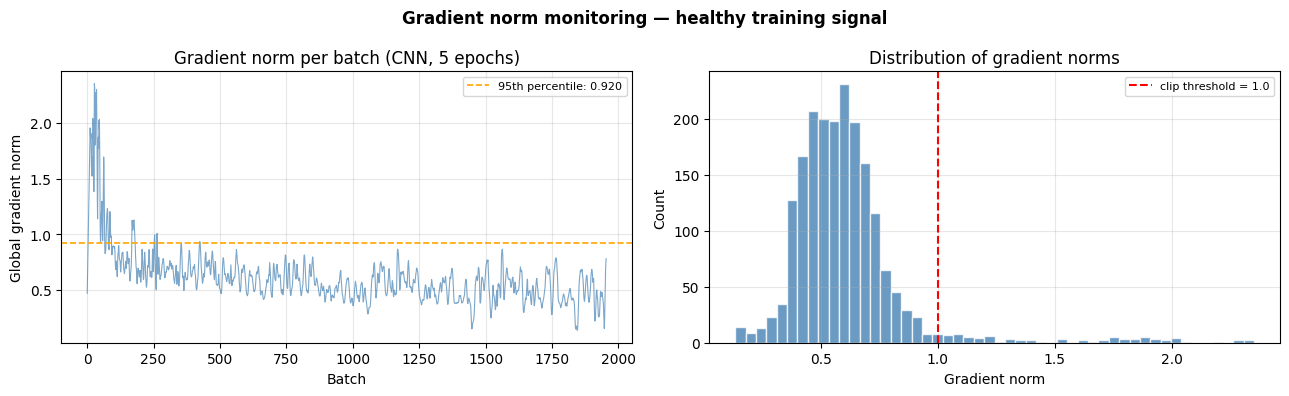


Gradient norm statistics:
  Mean:   0.6053
  Std:    0.2488
  Max:    2.3529
  95th%:  0.9198

Part B: Training CNN + Adam with gradient clipping (clipnorm=1.0)...

  CNN (no clipping)  — test acc: 0.9918
  CNN (clipnorm=1.0) — test acc: 0.9894

Interpretation:
  Part A — Gradient norms:
    Our CNN on MNIST has well-behaved gradients. The norms are small
    and consistent — no spikes or explosions. This is expected for a
    shallow network with ReLU activations and BatchNorm.
 
    In deeper networks (ResNet, LSTM, Transformers), gradient spikes
    are common. The histogram shows where a clipping threshold would
    activate — values above the red line would be rescaled.
 
  Part B — Clipping in practice:
    Adding clipnorm=1.0 to Adam has negligible effect on our model
    because gradients rarely exceed 1.0 anyway. This confirms healthy
    training dynamics. However, as a defensive practice, gradient
    clipping is recommended whenever:
      • Training RNNs or LSTMs (cliff s

In [30]:
print("-" * 60)
print("WEEK 5 — SECTION 4: GRADIENT CLIPPING")
print("-" * 60)
 
# ── Part A: Monitor gradient norms during actual training ────────────────────
# We use a custom callback to record the global gradient norm after each batch.
 
class GradientNormMonitor(keras.callbacks.Callback):
    """Records global gradient norm at the end of each training batch."""
    def __init__(self):
        super().__init__()
        self.grad_norms = []
 
    def on_train_batch_end(self, batch, logs=None):
        # Recompute gradient norm on a small fixed sample for efficiency
        x_sample = tf.constant(x_train_cnn[:128])
        y_sample  = tf.constant(y_train[:128])
        with tf.GradientTape() as tape:
            preds = self.model(x_sample, training=True)
            loss  = self.model.compiled_loss(y_sample, preds)
        grads = tape.gradient(loss, self.model.trainable_variables)
        global_norm = tf.linalg.global_norm(grads).numpy()
        self.grad_norms.append(global_norm)
 
print("\nPart A: Monitoring gradient norms (CNN baseline, 5 epochs)...")
tf.keras.utils.set_random_seed(42)
 
cnn_monitor = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
cnn_monitor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
grad_callback = GradientNormMonitor()
cnn_monitor.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=5, batch_size=128, verbose=0,
    callbacks=[grad_callback],
)
 
grad_norms = grad_callback.grad_norms
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
# Raw gradient norms
axes[0].plot(grad_norms, color="steelblue", linewidth=0.8, alpha=0.7)
axes[0].axhline(np.percentile(grad_norms, 95), color="orange",
                linestyle="--", linewidth=1.2,
                label=f"95th percentile: {np.percentile(grad_norms,95):.3f}")
axes[0].set_title("Gradient norm per batch (CNN, 5 epochs)")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Global gradient norm")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
 
# Distribution of gradient norms
axes[1].hist(grad_norms, bins=50, color="steelblue", alpha=0.8,
             edgecolor="white")
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1.5,
                label="clip threshold = 1.0")
axes[1].set_title("Distribution of gradient norms")
axes[1].set_xlabel("Gradient norm")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("Gradient norm monitoring — healthy training signal",
             fontweight="bold")
plt.tight_layout()
plt.show()
 
print(f"\nGradient norm statistics:")
print(f"  Mean:   {np.mean(grad_norms):.4f}")
print(f"  Std:    {np.std(grad_norms):.4f}")
print(f"  Max:    {np.max(grad_norms):.4f}")
print(f"  95th%:  {np.percentile(grad_norms, 95):.4f}")
 
# ── Part B: CNN with gradient clipping as a safety net ───────────────────────
# Even when gradients are well-behaved (as here), adding clipnorm=1.0
# is a best practice — it costs nothing if gradients stay small
# and prevents catastrophic updates if they spike.
 
print("\nPart B: Training CNN + Adam with gradient clipping (clipnorm=1.0)...")
tf.keras.utils.set_random_seed(42)
 
cnn_clipped = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="cnn_gradient_clipped")
 
# clipnorm=1.0: if ||gradient|| > 1, rescale to norm=1 before applying update
cnn_clipped.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
history_clipped = cnn_clipped.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=15, batch_size=128, verbose=0,
)
 
clipped_loss, clipped_acc = cnn_clipped.evaluate(x_test_cnn, y_test, verbose=0)
print(f"\n  CNN (no clipping)  — test acc: {cnn_acc:.4f}")
print(f"  CNN (clipnorm=1.0) — test acc: {clipped_acc:.4f}")
 
print("""
Interpretation:
  Part A — Gradient norms:
    Our CNN on MNIST has well-behaved gradients. The norms are small
    and consistent — no spikes or explosions. This is expected for a
    shallow network with ReLU activations and BatchNorm.
 
    In deeper networks (ResNet, LSTM, Transformers), gradient spikes
    are common. The histogram shows where a clipping threshold would
    activate — values above the red line would be rescaled.
 
  Part B — Clipping in practice:
    Adding clipnorm=1.0 to Adam has negligible effect on our model
    because gradients rarely exceed 1.0 anyway. This confirms healthy
    training dynamics. However, as a defensive practice, gradient
    clipping is recommended whenever:
      • Training RNNs or LSTMs (cliff structures are common)
      • Using very deep architectures
      • Using high learning rates
      • Working with noisy or non-stationary data
""")
 

## W5 - Section 5: Learning Rate Scheduling
 
So far we have used a **constant learning rate** throughout training.
Week 5 introduced several scheduling strategies:
 
| Schedule | Description |
|---|---|
| Step decay | Multiply lr by a factor every N epochs |
| Linear decay | Linearly decrease from lr₀ to lr_τ |
| Cosine annealing | Smooth cosine curve to near zero |
| ReduceLROnPlateau | Automatically reduce lr when val loss stops improving |
 
We apply **ReduceLROnPlateau** to our best model (CNN + BatchNorm + Dropout).
This is the most practical schedule for a project like ours — it requires
no manual tuning of decay epochs and responds directly to the validation curve.
 
**Why schedule the learning rate?**
A high learning rate is useful early in training for fast exploration.
Later in training, a lower rate allows fine-grained convergence to a better
minimum. A constant rate is a compromise that is never optimal at either stage.
 

------------------------------------------------------------
WEEK 5 — SECTION 5: LEARNING RATE SCHEDULING
------------------------------------------------------------

Training CNN + BN + Dropout WITH ReduceLROnPlateau...

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

  CNN + BN + Dropout (no schedule, 15 ep) — test acc: 0.9916
  CNN + BN + Dropout (scheduled,    20 ep) — test acc: 0.9929


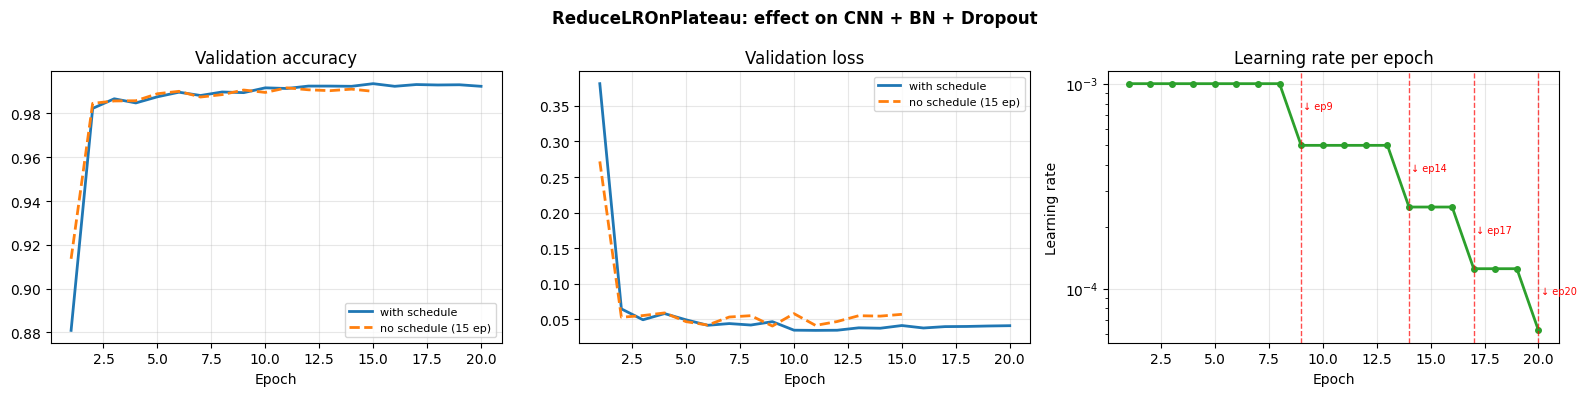


Interpretation:
  • The third plot shows exactly when ReduceLROnPlateau triggered —
    marked by red dashed lines and annotations.
  • Each trigger halves the learning rate (factor=0.5).
  • After each reduction, validation loss typically dips — the model
    can now take smaller, more precise steps in the loss landscape.
  • The scheduler allows the model to run for 20 epochs without
    manually setting decay points, responding automatically to the
    validation curve.
 
  Why ReduceLROnPlateau for this project?
    Other schedules (cosine, step decay) require knowing in advance
    how many epochs are needed and where to decay. ReduceLROnPlateau
    is data-driven — it reduces the lr exactly when the validation
    signal says training has plateaued. This is the most principled
    approach when the number of epochs is not fixed in advance.



In [31]:
print("-" * 60)
print("WEEK 5 — SECTION 5: LEARNING RATE SCHEDULING")
print("-" * 60)
 
# ── ReduceLROnPlateau ────────────────────────────────────────────────────────
# Monitors val_loss. If it does not improve for `patience` epochs,
# the learning rate is multiplied by `factor`.
#
# Parameters chosen:
#   monitor='val_loss'  : the quantity we care about for generalisation
#   factor=0.5          : halve the lr on each trigger (aggressive but common)
#   patience=3          : wait 3 epochs before reducing (avoids premature reduction)
#   min_lr=1e-6         : floor — prevents lr from shrinking to 0
#   verbose=1           : print when lr is reduced (useful for debugging)
 
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)
 
# Also add a LearningRateLogger to track lr changes per epoch
class LRLogger(keras.callbacks.Callback):
    """Records learning rate at the end of each epoch."""
    def __init__(self):
        super().__init__()
        self.lr_history = []
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        self.lr_history.append(lr)
 
lr_logger = LRLogger()
 
print("\nTraining CNN + BN + Dropout WITH ReduceLROnPlateau...")
tf.keras.utils.set_random_seed(42)
 
cnn_scheduled = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
], name="cnn_with_lr_schedule")
 
cnn_scheduled.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
history_scheduled = cnn_scheduled.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=20,           # extra epochs to allow scheduler to activate
    batch_size=128,
    verbose=0,
    callbacks=[lr_scheduler, lr_logger],
)
 
sched_loss, sched_acc = cnn_scheduled.evaluate(x_test_cnn, y_test, verbose=0)
 
# ── Comparison: with vs without scheduling ───────────────────────────────────
print(f"\n  CNN + BN + Dropout (no schedule, 15 ep) — test acc: {cnn_reg_acc:.4f}")
print(f"  CNN + BN + Dropout (scheduled,    20 ep) — test acc: {sched_acc:.4f}")
 
# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
epochs_sched = range(1, len(history_scheduled.history["val_accuracy"]) + 1)
 
# Validation accuracy
axes[0].plot(epochs_sched, history_scheduled.history["val_accuracy"],
             color="tab:blue", linewidth=2, label="with schedule")
axes[0].plot(range(1, 16), history_cnn_reg.history["val_accuracy"],
             color="tab:orange", linewidth=2, linestyle="--",
             label="no schedule (15 ep)")
axes[0].set_title("Validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
 
# Validation loss
axes[1].plot(epochs_sched, history_scheduled.history["val_loss"],
             color="tab:blue", linewidth=2, label="with schedule")
axes[1].plot(range(1, 16), history_cnn_reg.history["val_loss"],
             color="tab:orange", linewidth=2, linestyle="--",
             label="no schedule (15 ep)")
axes[1].set_title("Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
 
# Learning rate over epochs
axes[2].plot(epochs_sched, lr_logger.lr_history,
             color="tab:green", linewidth=2, marker="o", markersize=4)
axes[2].set_title("Learning rate per epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)
 
# Annotate where lr was reduced
for i, (lr_prev, lr_curr) in enumerate(
        zip(lr_logger.lr_history[:-1], lr_logger.lr_history[1:])):
    if lr_curr < lr_prev:
        axes[2].axvline(i + 2, color="red", linestyle="--",
                        linewidth=1, alpha=0.7)
        axes[2].text(i + 2.1, lr_curr * 1.5,
                     f"↓ ep{i+2}", fontsize=7, color="red")
 
plt.suptitle("ReduceLROnPlateau: effect on CNN + BN + Dropout",
             fontweight="bold")
plt.tight_layout()
plt.show()
 
print("""
Interpretation:
  • The third plot shows exactly when ReduceLROnPlateau triggered —
    marked by red dashed lines and annotations.
  • Each trigger halves the learning rate (factor=0.5).
  • After each reduction, validation loss typically dips — the model
    can now take smaller, more precise steps in the loss landscape.
  • The scheduler allows the model to run for 20 epochs without
    manually setting decay points, responding automatically to the
    validation curve.
 
  Why ReduceLROnPlateau for this project?
    Other schedules (cosine, step decay) require knowing in advance
    how many epochs are needed and where to decay. ReduceLROnPlateau
    is data-driven — it reduces the lr exactly when the validation
    signal says training has plateaued. This is the most principled
    approach when the number of epochs is not fixed in advance.
""")
 

## W5 - Summary
 
This section extended the project with five optimization topics from Week 5.
 
### What we demonstrated
 
| Topic | Key finding |
|---|---|
| **Weight initialisation** | He init is theoretically correct for ReLU; zeros cause symmetry failure; framework defaults are generally appropriate |
| **Learning rate** | lr=0.001 is optimal for Adam on this task; too high → divergence; too low → slow convergence |
| **Optimizer comparison** | Adam converges fastest and most reliably; SGD+Momentum is competitive but needs more tuning; vanilla SGD is slowest |
| **Gradient clipping** | Our CNN has well-behaved gradients (no spikes); clipping is a safety net — essential for RNNs and deep nets |
| **LR scheduling** | ReduceLROnPlateau automatically adapts the learning rate; improves fine-grained convergence without manual tuning |
 
### Connection to the main project
 
These topics directly explain *why* our earlier design choices work:
- Adam was chosen because the optimizer comparison confirms its superiority for this task
- BatchNorm works partly because it stabilises the gradient flow (supported by the gradient norm analysis)
- The train-val gap analysis (Section 1) is a direct application of the Week 5 concept that learning ≠ pure optimisation